# Analysis of skills centrality based on final GBN classification
Felix Zaussinger | 29.08.2022

**Core Analysis Goal(s)**
1. Merge skills centrality data to most recent ESCO version
2. Analyse differences in centrality between GBN occupations
3. Visualise (boxplots, test statistics)

**Key Insight(s)**
1.
2.
3.

In [314]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
#sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [382]:
meanprops={"marker":"o",
            "markerfacecolor":"white",
            "markeredgecolor":"black",
            "markersize":"3"}

Read final classifications

In [182]:
df_sl = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists.csv"),
    index_col=0
)

df_sl_tobi = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists_tobi.csv"),
    index_col=0
)

Read skills data with coreness

In [67]:
from src.data.framework import Esco

esco = Esco()
smd = esco.combine_skills_metadata()

cols = ['conceptUri', 'skillType', 'reuseLevel',
       'preferredLabel', 'description', 'coreness', 'skill_classification_esco']

smd = smd[cols]

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


cross-sector vs. sector-specific: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.554e+03
cross-sector vs. transversal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.268e-198 Stat=9.029e+02
cross-sector vs. occupation-specific: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=5.100e+03


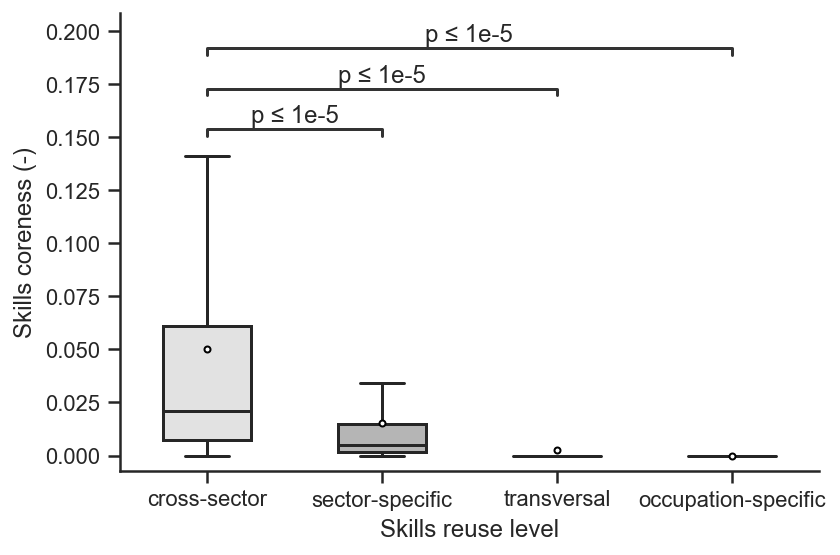

In [397]:


# configure
y = "coreness"
x = "reuseLevel"
df = smd
order = smd.groupby("reuseLevel").mean().sort_values("coreness", ascending=False).index.values
pairs = [
    ("cross-sector", "sector-specific"),
    ("cross-sector", "transversal"),
    ("cross-sector", "occupation-specific"),
]

# plot
ax = sns.boxplot(data=df, x=x, y=y, fliersize=1, order=order, showmeans=True, meanprops=meanprops, width=.5, showfliers=False, palette="Greys")
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(test='Kruskal', comparisons_correction="Benjamini-Hochberg", text_format='simple', loc='inside', show_test_name=False)
annotator.apply_and_annotate()

# label
ax.set_xlabel("Skills reuse level")
ax.set_ylabel("Skills coreness (-)")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(useful_paths.figure_dir, "skills_centrality", "coreness_by_reuse_level.png"),
    dpi=300
)

Missing coreness values
- 512 or 3% missing values
- 143 (of 570 green skills in total) of the missing values are classified as green, which is quite a lot... (25%)

In [68]:
utils.perc_missing(smd)

,abs,rel
conceptUri,0.0,0.000000
skillType,1.0,0.000072
reuseLevel,0.0,0.000000
preferredLabel,0.0,0.000000
description,0.0,0.000000
coreness,512.0,0.036858
skill_classification_esco,0.0,0.000000


In [71]:
smd.groupby("skill_classification_esco").count()

,conceptUri,skillType,reuseLevel,preferredLabel,description,coreness
skill_classification_esco,,,,,,
brown,477,477,477,477,477,477
green,570,570,570,570,570,427
neutral,12844,12843,12844,12844,12844,12475


In [70]:
smd[smd.coreness.isna()].groupby("skill_classification_esco").count()

,conceptUri,skillType,reuseLevel,preferredLabel,description,coreness
skill_classification_esco,,,,,,
green,143,143,143,143,143,0
neutral,369,368,369,369,369,0


In [72]:
143/570

0.25087719298245614

Read occupation-skills matrices

In [148]:
osm_wtd = esco.read_occ_skills_matrix(return_version="weighted", weight_optional=0.5)
osm_uniform = esco.read_occ_skills_matrix(return_version="unweighted")

In [153]:
np.unique(osm_wtd.values.flatten())

array([0. , 0.5, 1. ])

Combine coreness with OSMs

In [165]:
osm = osm_wtd
assert np.all(osm.columns.values == smd.conceptUri.values)

coreness_tiled = np.tile(smd.coreness.values, (3008, 1))
osm_coreness = osm.mul(coreness_tiled)

conceptUri,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,http://data.europa.eu/esco/skill/00064735-8fad-454b-90c7-ed858cc993f2,http://data.europa.eu/esco/skill/000709ed-2be5-4193-b056-45a97698d828,http://data.europa.eu/esco/skill/0007bdc2-dd15-4824-b7d6-416522c46f35,http://data.europa.eu/esco/skill/00090cc1-1f27-439e-a4e0-19a87a501bfc,http://data.europa.eu/esco/skill/000bb1e4-89f0-4b86-be05-05ece3641724,http://data.europa.eu/esco/skill/000c94d2-2a2e-4545-993c-6df8cb5b0316,http://data.europa.eu/esco/skill/000f1d3d-220f-4789-9c0a-cc742521fb02,http://data.europa.eu/esco/skill/001115fb-569f-4ee6-8381-c6807ef2527f,http://data.europa.eu/esco/skill/001d46db-035e-4b92-83a3-ed8771e0c123,http://data.europa.eu/esco/skill/0023e7a5-43da-4b68-bee3-726ef21f986d,http://data.europa.eu/esco/skill/00298d97-3dc3-4086-a902-bce0a2fba831,http://data.europa.eu/esco/skill/002b2e58-35ab-460c-be97-ca2f585fd990,http://data.europa.eu/esco/skill/0037c821-2898-4919-b96e-7ed1cd89554c,http://data.europa.eu/esco/skill/004017c9-0337-4f5a-8077-798de9ef12e3,http://data.europa.eu/esco/skill/004f1e68-9ca2-4f3f-92d9-e7d7ff6b9330,http://data.europa.eu/esco/skill/00506f28-e884-4496-800c-3477c67eb355,http://data.europa.eu/esco/skill/0058526a-11e9-40a1-ab33-7c5ffdf5da05,http://data.europa.eu/esco/skill/00735755-adc6-4ea0-b034-b8caff339c9f,http://data.europa.eu/esco/skill/0082c13b-5866-4542-bc4f-722a4ae9530e,http://data.europa.eu/esco/skill/00831ebb-bac3-4bd1-8dae-2bca67be958d,http://data.europa.eu/esco/skill/0085e6bd-6829-4e8e-b302-842a7fe57ed9,http://data.europa.eu/esco/skill/008a0e0d-7380-4b31-abe5-0195e700f8c0,http://data.europa.eu/esco/skill/008fa98b-dba6-4abf-909e-04299728e3eb,http://data.europa.eu/esco/skill/00920055-eb50-4cb8-a23d-3deedbf3753e,http://data.europa.eu/esco/skill/009673d9-e2fd-46ef-a64b-6027ac7fd613,http://data.europa.eu/esco/skill/00994812-ac9e-4856-954b-f71bcc6066bb,http://data.europa.eu/esco/skill/009db49b-fcf5-4409-b4a5-232d059f3597,http://data.europa.eu/esco/skill/00a4e92d-e410-42b8-ba2d-d7b3febf49e0,http://data.europa.eu/esco/skill/00b9a3aa-7070-4bb5-8020-f228a97cf42f,http://data.europa.eu/esco/skill/00c04e40-35ea-4ed1-824c-82f936c8f876,http://data.europa.eu/esco/skill/00c51318-4ea9-4d37-9cd8-74680583d203,http://data.europa.eu/esco/skill/00c85cbc-2b24-4605-a6fe-55b5c615e3fe,http://data.europa.eu/esco/skill/00cd1d60-782f-48e7-9a7b-b518f2b146b8,http://data.europa.eu/esco/skill/00dd3271-077f-4a12-a958-e297fdd724ce,http://data.europa.eu/esco/skill/00e261cc-669c-4b94-8950-d038eceb92d8,http://data.europa.eu/esco/skill/00e53a0a-c0ba-4c9f-a2ed-4706d5832a00,http://data.europa.eu/esco/skill/00e895f4-b9d3-4a1a-8c36-baf10fbfb982,http://data.europa.eu/esco/skill/00eada7f-0b83-4f0c-af81-d7f92d838000,http://data.europa.eu/esco/skill/00ebb379-ce26-439a-ba89-9a7d1ef2f696,http://data.europa.eu/esco/skill/00ec5333-e570-477b-9017-2e95fea0150a,http://data.europa.eu/esco/skill/00eefa32-9f77-4500-abe9-20afc7924a9d,http://data.europa.eu/esco/skill/00f12ec1-b416-4e3c-8ed7-c4f875c6b681,http://data.europa.eu/esco/skill/00f2eee1-cd4d-4a45-ae10-b6060f53ad5d,http://data.europa.eu/esco/skill/00fc7575-0cee-4b12-ade5-795cb2a4479a,http://data.europa.eu/esco/skill/00ff06cc-103f-4c85-b5df-6f75acff6abf,http://data.europa.eu/esco/skill/011711eb-f20b-4d64-84d7-17b8979946dc,http://data.europa.eu/esco/skill/0121ac3b-775b-4faf-b86d-0078623674bc,http://data.europa.eu/esco/skill/01267c89-b27f-4de0-b555-3683c5a5d66e,http://data.europa.eu/esco/skill/012795fe-5f85-4d12-a10e-9dabda4ea05f,http://data.europa.eu/esco/skill/012d6406-016a-4790-aeb8-853e61058517,http://data.europa.eu/esco/skill/012f9ad1-b95b-42f1-b2c7-3793cdbce443,http://data.europa.eu/esco/skill/0132ac4f-ffac-4396-8b56-052fde0c9d73,http://data.europa.eu/esco/skill/013441c1-1f13-47e9-80c4-9a53e8e1bc05,http://data.europa.eu/esco/skill/0138fdc7-edbb-485c-9aa9-544f723eb62f,http://data.europa.eu/esco/skill/013a64b9-5e74-4f7f-af5b-9ec76715238b,http://data.europa.eu/esco/skill/01468114-b99c-4f48-9374-a520a7faa9c9

In [188]:
df_sl_ridx = df_sl.set_index("conceptUri").reindex(index=osm_coreness.index)
(osm.index == df_sl_ridx.index).all()

True

In [260]:
colsel = ["preferredLabel", "gbn_classification_short_list"]
osm_merged = pd.concat([osm, df_sl_ridx[colsel]], axis=1)

osm_merged_v1 = osm_merged.reset_index().set_index(["conceptUri", "preferredLabel", "gbn_classification_short_list"])
n_ess = osm_merged_v1[osm_merged_v1 == 1].count(axis=1).rename("essential").reset_index().set_index("conceptUri")
n_opt = osm_merged_v1[osm_merged_v1 == 0.5].count(axis=1).rename("optional").reset_index().set_index("conceptUri")

#### Differences in number of skills

In [261]:
n_skills_by_cat = osm_merged_v1[osm_merged_v1 > 0].count(axis=1).rename("total").reset_index().set_index("conceptUri")
n_skills_by_cat["essential"] = n_ess["essential"]
n_skills_by_cat["optional"] = n_opt["optional"]
n_skills_by_cat_long = n_skills_by_cat.melt(id_vars=["preferredLabel", "gbn_classification_short_list"], value_vars=["total", "essential", "optional"], var_name="skill_type", value_name="skills")
n_skills_by_cat_long = n_skills_by_cat_long.rename(columns={"gbn_classification_short_list": "classification"})

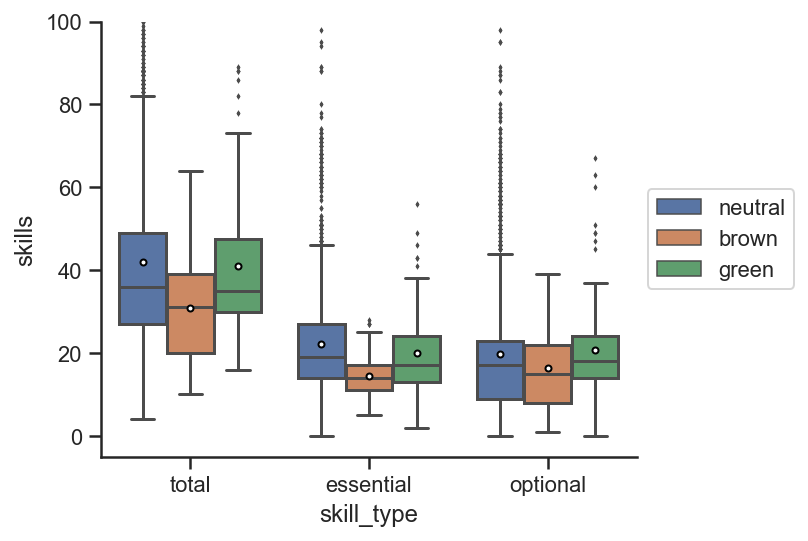

In [262]:
ax = sns.boxplot(data=n_skills_by_cat_long, x="skill_type", y="skills", hue="classification", fliersize=1, showmeans=True, meanprops=meanprops)

ax.set_ylim(-5, 100)
plotting_utils.move_legend_to_right(ax)
sns.despine()

Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction

essential_brown vs. essential_neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.401e-27 Stat=1.184e+02
optional_green vs. optional_brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:6.003e-03 Stat=7.549e+00
optional_brown vs. optional_neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.480e-01 Stat=1.335e+00
total_green vs. total_brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.450e-06 Stat=1.962e+01
total_brown vs. total_neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:6.685e-13 Stat=5.163e+01
essential_green vs. essential_brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.529e-07 Stat=2.594e+01
optional_green vs. optio

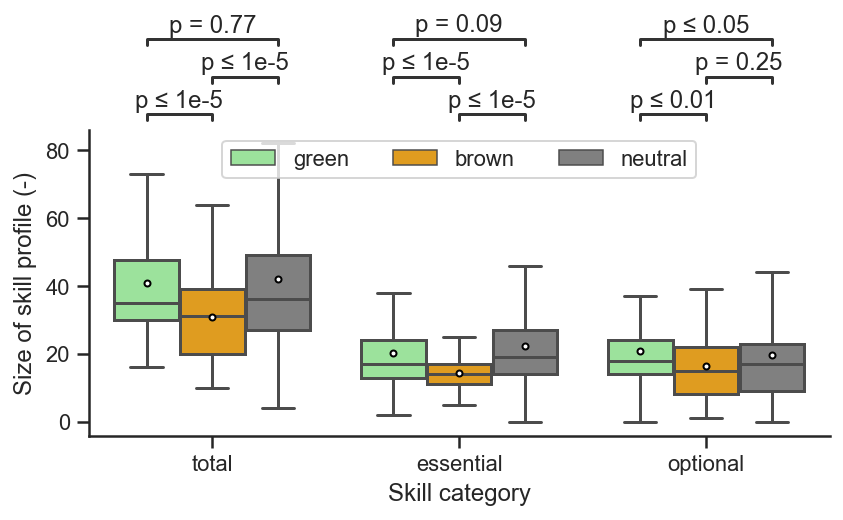

In [381]:
# configure
x = "skill_type"
y = "skills"
hue="classification"
df = n_skills_by_cat_long
order = ["total", "essential", "optional"]
hue_order = ["green", "brown", "neutral"]
hue_colors = ["lightgreen", "orange", "grey"]

pairs=[
    (("total", "green"), ("total", "brown")),
    (("total", "green"), ("total", "neutral")),
    (("total", "brown"), ("total", "neutral")),
    (("essential", "green"), ("essential", "brown")),
    (("essential", "green"), ("essential", "neutral")),
    (("essential", "brown"), ("essential", "neutral")),
    (("optional", "green"), ("optional", "brown")),
    (("optional", "green"), ("optional", "neutral")),
    (("optional", "brown"), ("optional", "neutral")),
    ]

# plot
#f, ax = plt.subplots(figsize=(10, 10))
ax = sns.boxplot(data=df, x=x, y=y, hue=hue, fliersize=1, order=order, hue_order=hue_order, palette=hue_colors, showmeans=True, meanprops=meanprops, width=.8, showfliers = False)
plotting_utils.move_legend_to_top(ax, scale=1, ncol=3, upper_anchor=1)
sns.despine()

# test statistic
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order)
annotator.configure(test='Kruskal', comparisons_correction="Benjamini-Hochberg", text_format='simple', loc='outside', show_test_name=False)
annotator.apply_and_annotate()


# label
ax.set_ylabel("Size of skill profile (-)")
ax.set_xlabel("Skill category")

# save
plt.tight_layout(w_pad=1.2)
plt.savefig(
    os.path.join(useful_paths.figure_dir, "skills_centrality", "n_skills_by_gbn_category.png"),
    dpi=300
)

In [263]:
import scikit_posthocs as sp

res = []
for skill_type in ["total", "essential", "optional"]:
    skill_type_query = "'" + "{}".format(skill_type) + "'"
    dfm = n_skills_by_cat_long.query("skill_type == {}".format(skill_type_query))

    pvals = sp.posthoc_dunn(
        dfm,
        val_col="skills",
        group_col="classification",
        p_adjust="bonferroni"
    ).unstack().rename(skill_type)

    res.append(pvals)

posthoc_dunn = pd.concat(res, axis=1)
posthoc_dunn

total     essential  optional
brown   brown    1.000000e+00  1.000000e+00  1.000000
        green    3.590951e-05  4.465694e-06  0.036933
        neutral  1.956050e-12  3.501636e-27  0.726293
green   brown    3.590951e-05  4.465694e-06  0.036933
        green    1.000000e+00  1.000000e+00  1.000000
        neutral  1.000000e+00  2.705363e-01  0.091706
neutral brown    1.956050e-12  3.501636e-27  0.726293
        green    1.000000e+00  2.705363e-01  0.091706
        neutral  1.000000e+00  1.000000e+00  1.000000

In [264]:
res = []
for skill_type in ["total", "essential", "optional"]:
    skill_type_query = "'" + "{}".format(skill_type) + "'"
    dfm = n_skills_by_cat_long.query("skill_type == {}".format(skill_type_query))

    pvals = sp.posthoc_ttest(
        dfm,
        val_col="skills",
        group_col="classification",
        p_adjust="bonferroni"
    ).unstack().rename(skill_type)

    res.append(pvals)

posthoc_ttest = pd.concat(res, axis=1)
posthoc_ttest

total     essential  optional
neutral neutral  1.000000e+00  1.000000e+00  1.000000
        brown    2.830980e-09  1.323102e-18  0.111956
        green    1.000000e+00  2.992142e-01  1.000000
brown   neutral  2.830980e-09  1.323102e-18  0.111956
        brown    1.000000e+00  1.000000e+00  1.000000
        green    1.131918e-07  3.097844e-10  0.003948
green   neutral  1.000000e+00  2.992142e-01  1.000000
        brown    1.131918e-07  3.097844e-10  0.003948
        green    1.000000e+00  1.000000e+00  1.000000

#### Differences in skills centrality

In [ ]:
osm_coreness_merged = pd.concat([osm_coreness, df_sl_ridx[colsel]], axis=1)
osm_coreness_merged_v2 = osm_coreness_merged.reset_index().set_index(["conceptUri", "preferredLabel", "gbn_classification_short_list"])

Aggregate by mean or median?
--> distribution very right-skewed, use median

<AxesSubplot:>

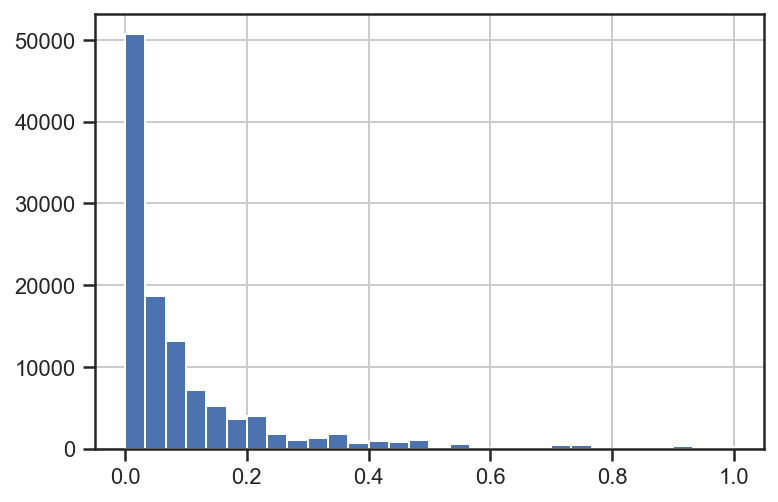

In [318]:
coreness_1d = osm_coreness_merged_v2[osm_coreness_merged_v2 > 0].stack()
coreness_1d.hist(bins=30)

In [281]:
osm_coreness_merged_v2_agg = pd.concat(
    [
        osm_coreness_merged_v2[osm_coreness_merged_v2 > 0].mean(axis=1).rename("coreness_mean"),
        osm_coreness_merged_v2[osm_coreness_merged_v2 > 0].median(axis=1).rename("coreness_median")
    ],
    axis=1
)

osm_coreness_merged_v2_agg = osm_coreness_merged_v2_agg.reset_index()
osm_coreness_merged_v2_agg = osm_coreness_merged_v2_agg.rename(columns={"gbn_classification_short_list": "classification"})

Statsannotations: t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal

The Shapiro-Wilk test. This test compares our distribution with a normal distribution (like in our plot) and tells us whether our distribution is significantly different from it. Thus, if the test is not significant, the distribution of our data is not significantly different from a normal distribution, or in simple terms: It is normally distributed.

https://bookdown.org/daniel_dauber_io/r4np_book/sources-of-bias.html

In [303]:
print("median: ", stats.shapiro(osm_coreness_merged_v2_agg.coreness_median))
print("mean: ", stats.shapiro(osm_coreness_merged_v2_agg.coreness_mean))

median:  ShapiroResult(statistic=0.9098488688468933, pvalue=5.1860010268903566e-39)
mean:  ShapiroResult(statistic=0.9768765568733215, pvalue=1.0380472472170858e-21)


Coreness not normally distributed --> use non-parametric tests

green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:6.541e-07 Stat=2.475e+01
brown vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:5.567e-01 Stat=3.454e-01
green vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.159e-07 Stat=2.410e+01


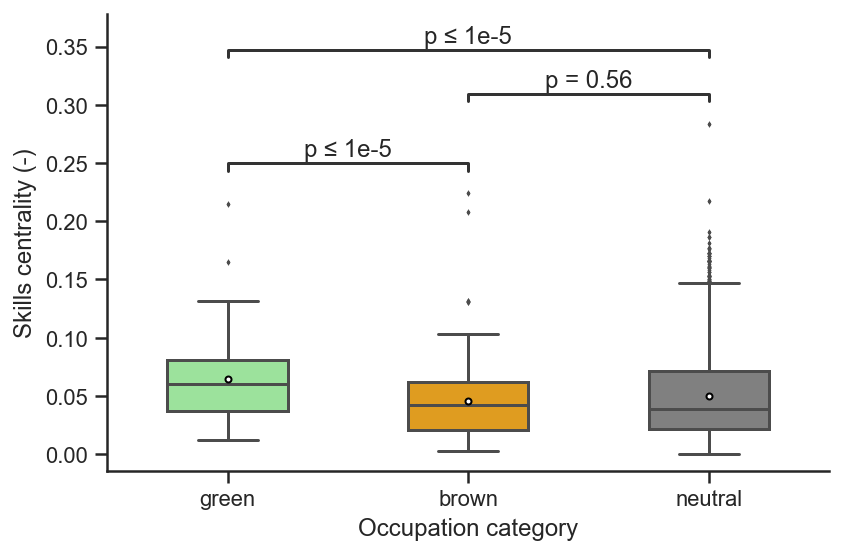

In [359]:
# configure
x = "classification"
y = "coreness_median"
df = osm_coreness_merged_v2_agg
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

# plot
ax = sns.boxplot(data=df, x=x, y=y, fliersize=1, order=order, palette=["lightgreen", "orange", "grey"], showmeans=True, meanprops=meanprops, width=.5)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(test='Kruskal', comparisons_correction="Benjamini-Hochberg", text_format='simple', loc='inside', show_test_name=False)
annotator.apply_and_annotate()

# label
ax.set_ylabel("Skills centrality (-)")
ax.set_xlabel("Occupation category")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(useful_paths.figure_dir, "skills_centrality", "median_skills_coreness_by_gbn_category.png"),
    dpi=300
)

Cohen's D suggests medium effect size

In [328]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'green'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'brown'").coreness_median
)

0.5877963486084565

In [329]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'green'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'neutral'").coreness_median
)

0.4097739925279315

In [330]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'brown'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'neutral'").coreness_median
)

-0.10618584028153004

<AxesSubplot:xlabel='coreness_median', ylabel='Count'>

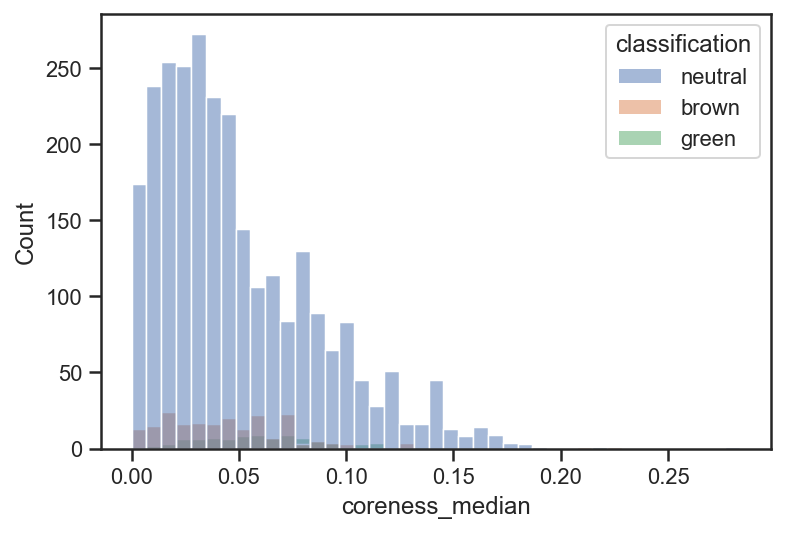

In [298]:
sns.histplot(osm_coreness_merged_v2_agg, x="coreness_median", hue="classification")

green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.213e-01 Stat=9.837e-01
brown vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.469e-02 Stat=5.046e+00
green vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.960e-03 Stat=9.586e+00


(<AxesSubplot:xlabel='classification', ylabel='coreness_mean'>,
  <statannotations.Annotation.Annotation at 0x245003d1190>])

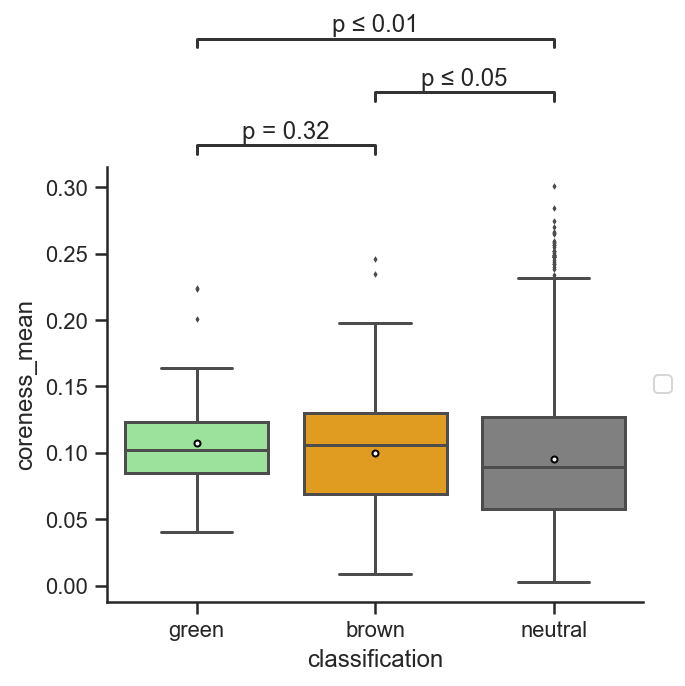

In [324]:
# configure
x = "classification"
y = "coreness_mean"
df = osm_coreness_merged_v2_agg
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

# plot
ax = sns.boxplot(data=df, x=x, y=y, fliersize=1, order=order, palette=["lightgreen", "orange", "grey"], showmeans=True, meanprops=meanprops)
plotting_utils.move_legend_to_right(ax)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(test='Kruskal', comparisons_correction="Benjamini-Hochberg", text_format='simple', loc='outside', show_test_name=False)
annotator.apply_and_annotate()